In [1]:
from NN_model_helper import (evaluate_fold_TL, set_freeze_mode, plot_training_progress, find_optimal_clusters)
from pathlib import Path
import sys
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import numpy as np
from NN_model import ImprovedNN 

/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_prefix_MW = '../MW/artifacts_threshold/'

df = pd.read_parquet(data_prefix_MW + "scaled_final_dataset_RDKit_60(split)_MW(label)_60(threshold).parquet")
df.head()

,SMILES,MP,Type,MW_label,RDKit_PEOE_VSA3,RDKit_VSA_EState9,RDKit_EState_VSA7,RDKit_Chi2n,RDKit_MaxAbsEStateIndex,RDKit_SlogP_VSA4,...,RDKit_fr_azide,RDKit_BCUT2D_MRLOW,RDKit_fr_quatN,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_LabuteASA,RDKit_SMR_VSA1,RDKit_MolWt,RDKit_PEOE_VSA9
0,OC(=O)C(CCl)Cl,50.0,Train,0,-0.654237,-0.158241,-0.709125,-1.262370,-0.108535,-0.654678,...,-0.026038,-0.637920,-0.036835,-0.450835,-0.036961,-0.455798,-1.192190,-0.151018,-1.024159,-0.952553
1,BrCc1c(CBr)c(CBr)c(c(c1CBr)CBr)CBr,292.0,Train,1,-0.654237,-0.158241,-0.709125,-0.154195,-2.227378,-0.654678,...,-0.026038,1.743540,-0.036835,-0.450835,-0.682878,-0.455798,1.326878,-1.101377,3.671337,-0.952553
2,COC(=O)c1ccc(cc1[N+](=O)[O-])C(=O)O,175.0,Train,0,1.461234,0.542313,-0.709125,-0.516638,0.390127,0.393353,...,-0.026038,-1.121697,-0.036835,-0.219191,0.098131,-0.455798,-0.295318,1.236425,-0.240879,1.043138
3,COC(=O)c1cccc(c1)O,71.0,Train,0,0.403499,0.683312,-0.709125,-0.820480,0.280962,-0.654678,...,-0.026038,-0.257927,-0.036835,-0.213605,0.098131,-0.455798,-0.883738,0.303652,-0.936669,0.484767
4,OC(=O)c1cc(F)cc(c1)F,121.0,Train,0,2.340660,-0.158241,-0.709125,-0.852599,0.786887,0.550866,...,-0.026038,-0.239395,-0.036835,0.861591,-0.682878,-0.455798,-0.957290,0.691814,-0.879925,-0.321582


In [3]:
df_highMW = df[
    (df["Type"] == "Train") &
    (df["MW_label"] == 1)
].copy()

print("Shape:", df_highMW.shape)
print(df_highMW[["Type", "MW_label"]].value_counts())

Shape: (4132, 144)
Type   MW_label
Train  1           4132
Name: count, dtype: int64


In [4]:
df_highMW.head()

,SMILES,MP,Type,MW_label,RDKit_PEOE_VSA3,RDKit_VSA_EState9,RDKit_EState_VSA7,RDKit_Chi2n,RDKit_MaxAbsEStateIndex,RDKit_SlogP_VSA4,...,RDKit_fr_azide,RDKit_BCUT2D_MRLOW,RDKit_fr_quatN,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_LabuteASA,RDKit_SMR_VSA1,RDKit_MolWt,RDKit_PEOE_VSA9
1,BrCc1c(CBr)c(CBr)c(c(c1CBr)CBr)CBr,292.0,Train,1,-0.654237,-0.158241,-0.709125,-0.154195,-2.227378,-0.654678,...,-0.026038,1.743540,-0.036835,-0.450835,-0.682878,-0.455798,1.326878,-1.101377,3.671337,-0.952553
7,Brc1cc(F)c(c(c1)Br)N,63.0,Train,1,0.314344,-0.158241,-0.709125,-0.926190,0.915875,-0.051906,...,-0.026038,0.850406,-0.036835,0.291459,-0.053036,-0.455798,-0.639734,-0.679960,0.176126,-0.307526
8,N#Cc1ccc(c(c1)[N+](=O)[O-])/C=C/c1ccc(cc1)/C=C...,350.0,Train,1,-0.654237,-0.158241,-0.069217,1.048834,0.420616,3.789611,...,-0.026038,-1.121666,-0.036835,-0.450835,-0.682878,-0.455798,1.878875,-0.156244,1.638947,4.064742
9,OC1CCC2(C(=CC(=O)C3C2CCC2(C3CCC2=O)C)C1)C,238.0,Train,1,-0.654237,-0.158241,-0.388813,1.834903,0.985228,2.307123,...,-0.026038,-0.644885,-0.036835,-0.450835,-0.682878,3.518967,0.693254,0.309188,0.495425,-0.260280
11,OC(=O)CC[C@H]([C@H]1CC[C@@H]2[C@]1(C)C(=O)C[C@...,237.0,Train,1,-0.654237,-0.158241,-0.709125,2.780696,1.244354,4.146738,...,-0.026038,-0.697293,-0.036835,-0.450835,-0.682878,3.518967,1.647585,1.229600,1.449587,-0.952553


X_scaled shape: (4132, 140)
Num features: 140


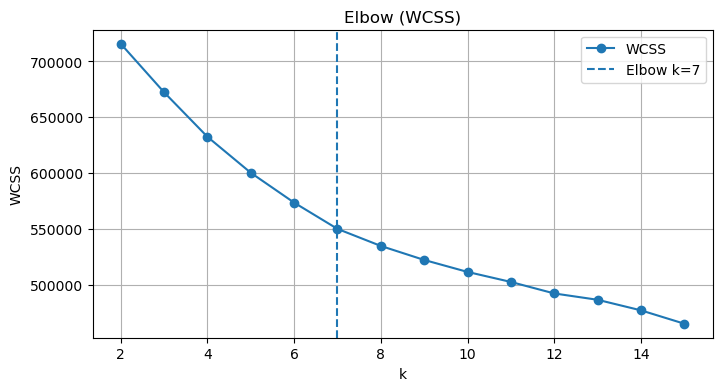

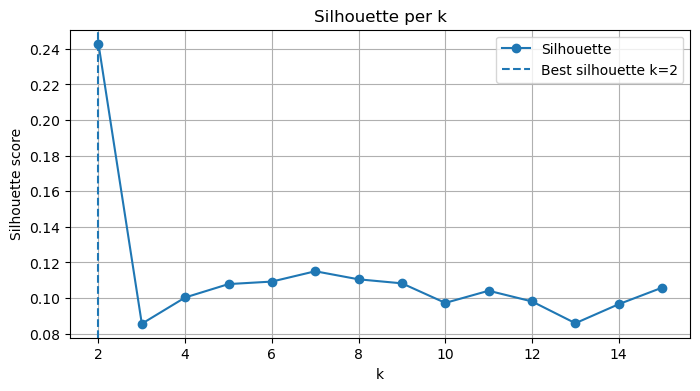

Elbow k: 7 | Best silhouette k: 2 | Selected k_opt: 7


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator


# 2) Define feature columns (already scaled), Exclude metadata/labels/non-features

exclude = {"SMILES", "MP", "Type", "MW_label"}
num_cols = df_highMW.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X_scaled = df_highMW[feature_cols].to_numpy(dtype=np.float32)

print("X_scaled shape:", X_scaled.shape)
print("Num features:", len(feature_cols))


# 3) Find optimal k

random_state = 0
k_opt = find_optimal_clusters(X_scaled=X_scaled, max_k=15, random_state=random_state, plot=True)

if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")


# 4) Fit final kmeans + assign clusters

final_kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=random_state
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

assert len(cluster_labels) == len(df_highMW), "Cluster labels length != df rows (mismatch)."

df_clustered = df_highMW.copy()
df_clustered["Structure_Cluster"] = cluster_labels


In [6]:
df_clustered.head()

,SMILES,MP,Type,MW_label,RDKit_PEOE_VSA3,RDKit_VSA_EState9,RDKit_EState_VSA7,RDKit_Chi2n,RDKit_MaxAbsEStateIndex,RDKit_SlogP_VSA4,...,RDKit_BCUT2D_MRLOW,RDKit_fr_quatN,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_LabuteASA,RDKit_SMR_VSA1,RDKit_MolWt,RDKit_PEOE_VSA9,Structure_Cluster
1,BrCc1c(CBr)c(CBr)c(c(c1CBr)CBr)CBr,292.0,Train,1,-0.654237,-0.158241,-0.709125,-0.154195,-2.227378,-0.654678,...,1.743540,-0.036835,-0.450835,-0.682878,-0.455798,1.326878,-1.101377,3.671337,-0.952553,0
7,Brc1cc(F)c(c(c1)Br)N,63.0,Train,1,0.314344,-0.158241,-0.709125,-0.926190,0.915875,-0.051906,...,0.850406,-0.036835,0.291459,-0.053036,-0.455798,-0.639734,-0.679960,0.176126,-0.307526,0
8,N#Cc1ccc(c(c1)[N+](=O)[O-])/C=C/c1ccc(cc1)/C=C...,350.0,Train,1,-0.654237,-0.158241,-0.069217,1.048834,0.420616,3.789611,...,-1.121666,-0.036835,-0.450835,-0.682878,-0.455798,1.878875,-0.156244,1.638947,4.064742,5
9,OC1CCC2(C(=CC(=O)C3C2CCC2(C3CCC2=O)C)C1)C,238.0,Train,1,-0.654237,-0.158241,-0.388813,1.834903,0.985228,2.307123,...,-0.644885,-0.036835,-0.450835,-0.682878,3.518967,0.693254,0.309188,0.495425,-0.260280,4
11,OC(=O)CC[C@H]([C@H]1CC[C@@H]2[C@]1(C)C(=O)C[C@...,237.0,Train,1,-0.654237,-0.158241,-0.709125,2.780696,1.244354,4.146738,...,-0.697293,-0.036835,-0.450835,-0.682878,3.518967,1.647585,1.229600,1.449587,-0.952553,4


In [7]:
TARGET_COL = "MP"

exclude = {"SMILES", TARGET_COL, "Type", "MW_label", "Structure_Cluster"}
num_cols = df_clustered.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X = df_clustered[feature_cols].to_numpy(np.float32) 
y = df_clustered[TARGET_COL].to_numpy(np.float32)
y_strat = df_clustered["Structure_Cluster"].astype(str).to_numpy()

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
folds = [(tr, va) for tr, va in skf.split(X, y_strat)]

print("Total samples:", len(X))
print("Num features:", X.shape[1])
print("Num folds:", len(folds))
print()

for i, (tr_idx, va_idx) in enumerate(folds):
    print(
        f"Fold {i:2d} | "
        f"Train: {len(tr_idx):4d} | "
        f"Val: {len(va_idx):4d}"
    )


Total samples: 4132
Num features: 140
Num folds: 10

Fold  0 | Train: 3718 | Val:  414
Fold  1 | Train: 3718 | Val:  414
Fold  2 | Train: 3719 | Val:  413
Fold  3 | Train: 3719 | Val:  413
Fold  4 | Train: 3719 | Val:  413
Fold  5 | Train: 3719 | Val:  413
Fold  6 | Train: 3719 | Val:  413
Fold  7 | Train: 3719 | Val:  413
Fold  8 | Train: 3719 | Val:  413
Fold  9 | Train: 3719 | Val:  413


In [8]:
from pathlib import Path
import json, joblib, numpy as np, pandas as pd, torch, optuna

BASELINE_CKPT = Path("artifacts_threshold/general_best_LowMW_RDKit_60(split)_MW(label)_60(threshold)/general_best_fold_4.pt")

# --- scenarios: name, vector (for your notes), freeze_level used by evaluate_fold_TL ---

HIDDEN_LAYERS = [256, 128, 64]   # must match baseline arch
N_TRIALS      = 20

OUT_ROOT = Path("artifacts_threshold/TL_MW_RDKit_60(split)_MW(label)_60(threshold)")   # under the artifacts folder
OUT_ROOT.mkdir(parents=True, exist_ok=True)

def run_one_scenario(tag, freeze_vec, freeze_level):
    print(f"\n=== Scenario: {tag} | freeze={freeze_vec} (level={freeze_level}) ===")
    SCEN_OUT = OUT_ROOT / tag
    (SCEN_OUT / "trials").mkdir(parents=True, exist_ok=True)

    def objective_tl_fixed(trial):
        # fixed freeze level; tune the rest
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
        weight_decay  = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])
        dropout_rate  = trial.suggest_float("dropout_rate", 0.2, 0.5)

        trial_dir = SCEN_OUT / "trials" / f"trial_{trial.number:04d}"
        trial_dir.mkdir(parents=True, exist_ok=True)

        fold_metrics, rmses = [], []
        for fold_idx, (tr_idx, va_idx) in enumerate(folds):
            X_tr, y_tr = X[tr_idx], y[tr_idx]
            X_va, y_va = X[va_idx], y[va_idx]

            rmse, r2, q2, model, *_ = evaluate_fold_TL(
                trial=trial,
                fold_idx=fold_idx,
                X_train_scaled=X_tr, y_train=y_tr,
                X_val_scaled=X_va,   y_val=y_va,
                hidden_layers=HIDDEN_LAYERS, dropout_rate=dropout_rate,
                learning_rate=learning_rate, weight_decay=weight_decay,
                batch_size=batch_size, freeze_level=freeze_level,
                baseline_ckpt=BASELINE_CKPT,
                max_epochs=10**6, patience=30, min_delta=0.0,
                save_checkpoints=False
            )

            ckpt_path = trial_dir / f"fold_{fold_idx}_best.pth"
            torch.save(model.state_dict(), ckpt_path)

            fold_metrics.append({
                "fold": fold_idx,
                "rmse": float(rmse),
                "r2":   float(r2),
                "q2":   float(q2),
                "checkpoint": str(ckpt_path)
            })
            rmses.append(rmse)

        summary = {
            "scenario": tag,
            "freeze_vector": freeze_vec,
            "freeze_level": freeze_level,
            "trial_number": trial.number,
            "params": {
                "learning_rate": learning_rate,
                "weight_decay":  weight_decay,
                "batch_size":    batch_size,
                "dropout_rate":  dropout_rate,
                "hidden_layers": HIDDEN_LAYERS
            },
            "avg_rmse": float(np.mean(rmses)),
            "folds":    fold_metrics
        }
        with open(trial_dir / "summary.json", "w") as f:
            json.dump(summary, f, indent=2)

        return float(np.mean(rmses))

    # -- HPO
    study = optuna.create_study(direction="minimize")
    study.optimize(objective_tl_fixed, n_trials=N_TRIALS, gc_after_trial=True)

    # save study artifacts
    joblib.dump(study, SCEN_OUT / "study.joblib")
    study.trials_dataframe().to_csv(SCEN_OUT / "trials.csv", index=False)
    with open(SCEN_OUT / "best_params.json","w") as f:
        json.dump(study.best_params, f, indent=2)
    with open(SCEN_OUT / "best_value.txt","w") as f:
        f.write(f"{study.best_value:.6f}\n")
    print(f"[{tag}] Best avg RMSE: {study.best_value:.4f}")
    print(f"[{tag}] Best params:  {study.best_params}")

    # -- Final per-fold retrain with best params (to produce clean fold models + metrics)
    best = study.best_params
    FINAL_DIR = SCEN_OUT / "final_fold_models"
    FINAL_DIR.mkdir(parents=True, exist_ok=True)

    rows = []
    for fold_idx, (tr_idx, va_idx) in enumerate(folds):
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_va, y_va = X[va_idx], y[va_idx]

        rmse, r2, q2, model, *_ = evaluate_fold_TL(
            trial=None,
            fold_idx=fold_idx,
            X_train_scaled=X_tr, y_train=y_tr,
            X_val_scaled=X_va,   y_val=y_va,
            hidden_layers=HIDDEN_LAYERS,
            dropout_rate=best["dropout_rate"],
            learning_rate=best["learning_rate"],
            weight_decay=best["weight_decay"],
            batch_size=best["batch_size"],
            freeze_level=freeze_level,
            baseline_ckpt=BASELINE_CKPT,
            max_epochs=10**6, patience=30, min_delta=0.0,
            save_checkpoints=False
        )

        ckpt = FINAL_DIR / f"fold_{fold_idx}_best.pth"
        torch.save(model.state_dict(), ckpt)
        rows.append({"fold": fold_idx, "rmse": float(rmse), "r2": float(r2), "q2": float(q2), "checkpoint": str(ckpt)})

    cv_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    cv_df.to_csv(SCEN_OUT / "cv_final_metrics.csv", index=False)

    best_row = cv_df.iloc[0]
    manifest = {
        "scenario": tag,
        "freeze_vector": freeze_vec,
        "freeze_level": freeze_level,
        "best_fold": int(best_row["fold"]),
        "checkpoint": best_row["checkpoint"],
        "hidden_layers": HIDDEN_LAYERS,
        "best_params": best
    }
    with open(SCEN_OUT / "manifest.json","w") as f:
        json.dump(manifest, f, indent=2)

    print(f"[{tag}] Best fold: {manifest['best_fold']} → {manifest['checkpoint']}")
    return study, cv_df, manifest


# ---------- RUN ALL THREE ----------
SCENARIOS = [
    ("no_freeze",        [0,0,0], 0),
    ("freeze_fc1",       [1,0,0], 1),
    ("freeze_fc1_fc2",   [1,1,0], 2),
]

results = {}
for tag, vec, lvl in SCENARIOS:
    study, cv_df, manifest = run_one_scenario(tag, vec, lvl)
    results[tag] = {"best": study.best_value, "manifest": manifest}
print("\nSummary:", json.dumps(results, indent=2))

[I 2026-03-01 11:56:50,007] A new study created in memory with name: no-name-2e1dfa86-ddfd-4dbf-bafc-5635cb880b43



=== Scenario: no_freeze | freeze=[0, 0, 0] (level=0) ===
Fold 0: TL on cpu | freeze=0 | lr=0.000190854
Freeze Level 0: all layers trainable


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/NN_model_helper.py:432: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=de

[Fold 0] Epoch    1 | Train 64.3403 | Val 58.8022 | ES 0/30
[Fold 0] Epoch   50 | Train 38.6714 | Val 36.7769 | ES 3/30
[Fold 0] Epoch  100 | Train 35.9103 | Val 36.1697 | ES 25/30
[Fold 0] Early stopping at epoch 105 (best Val Loss: 35.9459)
Fold 1: TL on cpu | freeze=0 | lr=0.000190854
Freeze Level 0: all layers trainable


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/NN_model_helper.py:432: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=de

...

[Fold 7] Early stopping at epoch 45 (best Val Loss: 43.9126)
Fold 8: TL on cpu | freeze=2 | lr=0.00096259
Freeze Level 2: freezing 2 block(s)
[Fold 8] Epoch    1 | Train 60.3747 | Val 52.8780 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/NN_model_helper.py:432: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=de

[Fold 8] Epoch   50 | Train 45.7298 | Val 42.1315 | ES 9/30
[Fold 8] Early stopping at epoch 71 (best Val Loss: 40.9699)
Fold 9: TL on cpu | freeze=2 | lr=0.00096259
Freeze Level 2: freezing 2 block(s)
[Fold 9] Epoch    1 | Train 60.2853 | Val 48.1234 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/NN_model_helper.py:432: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=de

[Fold 9] Epoch   50 | Train 46.4678 | Val 40.0168 | ES 7/30
[Fold 9] Epoch  100 | Train 45.9304 | Val 40.0199 | ES 5/30
[Fold 9] Early stopping at epoch 125 (best Val Loss: 39.4999)
[freeze_fc1_fc2] Best fold: 9 → artifacts_threshold/TL_MW_RDKit_60(split)_MW(label)_60(threshold)/freeze_fc1_fc2/final_fold_models/fold_9_best.pth

Summary: {
  "no_freeze": {
    "best": 38.502678298950194,
    "manifest": {
      "scenario": "no_freeze",
      "freeze_vector": [
        0,
        0,
        0
      ],
      "freeze_level": 0,
      "best_fold": 0,
      "checkpoint": "artifacts_threshold/TL_MW_RDKit_60(split)_MW(label)_60(threshold)/no_freeze/final_fold_models/fold_0_best.pth",
      "hidden_layers": [
        256,
        128,
        64
      ],
      "best_params": {
        "learning_rate": 0.00019083864094777392,
        "weight_decay": 0.00014493847383236058,
        "batch_size": 32,
        "dropout_rate": 0.23942766111304598
      }
    }
  },
  "freeze_fc1": {
    "best": 39.26

In [14]:
from NN_model import ImprovedNN
import torch
import pandas as pd
from pathlib import Path
import json

def load_best_models_for_scenarios(
    root_dir="artifacts_threshold/TL_MW_RDKit_60(split)_MW(label)_60(threshold)",
    scenarios=("no_freeze", "freeze_fc1", "freeze_fc1_fc2"),
):
    root_dir = Path(root_dir)
    models = {}
    manifests = {}

    for tag in scenarios:
        manifest_path = root_dir / tag / "manifest.json"
        cv_metrics_path = root_dir / tag / "cv_final_metrics.csv"

        # Load manifest
        with open(manifest_path, "r") as f:
            manifest = json.load(f)
        manifests[tag] = manifest

        # Load best RMSE from cv_final_metrics.csv
        cv_df = pd.read_csv(cv_metrics_path)
        best_row = cv_df.sort_values("rmse").iloc[0]
        best_rmse = float(best_row["rmse"])

        # Load checkpoint
        ckpt_path = Path(best_row["checkpoint"]).resolve()
        state = torch.load(ckpt_path, map_location="cpu")

        # Build model
        input_size = state["network.0.weight"].shape[1]
        hidden_layers = manifest["hidden_layers"]
        dropout_rate = manifest["best_params"]["dropout_rate"]

        model = ImprovedNN(
            input_size=input_size,
            hidden_layers=hidden_layers,
            dropout_rate=dropout_rate,
        )
        model.load_state_dict(state)
        model.eval()

        models[tag] = model

        print(f"Loaded model for scenario '{tag}'")
        print(f"  └─ Best fold checkpoint: {ckpt_path}")
        print(f"  └─ Best RMSE: {best_rmse:.4f}\n")

    return models, manifests

models, manifests = load_best_models_for_scenarios(
    root_dir="artifacts_threshold/TL_MW_RDKit_60(split)_MW(label)_60(threshold)",
    scenarios=["no_freeze", "freeze_fc1", "freeze_fc1_fc2"]
)

Loaded model for scenario 'no_freeze'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts_threshold/TL_MW_RDKit_60(split)_MW(label)_60(threshold)/no_freeze/final_fold_models/fold_0_best.pth
  └─ Best RMSE: 36.3975

Loaded model for scenario 'freeze_fc1'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts_threshold/TL_MW_RDKit_60(split)_MW(label)_60(threshold)/freeze_fc1/final_fold_models/fold_0_best.pth
  └─ Best RMSE: 36.7786

Loaded model for scenario 'freeze_fc1_fc2'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts_threshold/TL_MW_RDKit_60(split)_MW(label)_60(threshold)/freeze_fc1_fc2/final_fold_models/fold_9_best.pth
  └─ Best RMSE: 39.8301



/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_87493/2964690177.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location="

TEST EVALUATION

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

In [19]:
df = pd.read_parquet("../MW/artifacts/final_dataset_RDKit_60_MW_scaled.parquet")
df.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_unbrch_alkane,RDKit_fr_NH0,RDKit_NumAliphaticRings,...,RDKit_SMR_VSA10,RDKit_RingCount,RDKit_FpDensityMorgan2,RDKit_fr_ester,RDKit_VSA_EState1,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_NumAtomStereoCenters,RDKit_SMR_VSA1,RDKit_PEOE_VSA9
0,CCOC(=O)/C(=C/c1ccc(o1)c1ccc(cc1)Cl)/C#N,140.0,Train,1,-0.463349,-0.150724,0.501978,-0.175089,0.199077,-0.497490,...,0.439775,0.104041,0.735690,1.519681,0.112624,-0.453481,-0.438297,-0.360924,0.237181,-0.207736
1,Brc1ccc2c(c1)c(=O)[nH]cc2,249.0,Train,0,1.259950,-0.150724,-0.661798,-0.175089,-0.674327,-0.497490,...,0.650404,0.104041,0.817902,-0.328623,-0.405680,0.348533,-0.691195,-0.360924,-1.118907,-0.952135
2,Nc1c(cnn1CCO)C(=O)N,239.0,Train,0,-0.463349,-0.150724,-0.661798,-0.175089,1.072481,-0.497490,...,-0.381838,-0.662138,1.585215,-0.328623,-0.383935,-0.453481,-0.452140,-0.360924,-0.156318,1.227865
3,OC(C=O)CO,145.0,Train,0,-0.463349,-0.150724,-0.661798,-0.175089,-0.674327,-0.497490,...,-0.756687,-1.428316,1.393386,-0.328623,-0.456272,-0.453481,-0.468240,0.182910,0.340142,-0.207736
4,CCOC(=O)C12C(c3cc(Br)ccc3O[P@@]2(=O)OCC)C2(C1c...,273.0,Train,1,-0.463349,-6.046404,-0.661798,-0.175089,-0.674327,2.339192,...,2.875673,2.402576,-1.445669,3.367986,3.181505,5.962631,1.129382,2.902081,3.381234,2.025463


In [20]:
df_test = df[
    (df["Type"] == "Test")
].copy()

print("Shape:", df_test.shape)

Shape: (6888, 69)


In [22]:
##################---------------------------- NO FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts_threshold/TL_MW_RDKit_60(split)_MW(label)_60(threshold)/no_freeze/final_fold_models/fold_0_best.pth"

OUT_PRED_CSV = BASE / "artifacts_threshold/test_TL_MW_predictions_no_freeze_RDKit_60(split)_MW(label)_60(threshold).csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [256, 128, 64]
DROPOUT_RATE =0.00019083864094777392   # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "MW_label"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "MW_label": df_test["MW_label"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_lowMW = out_df[out_df["MW_label"] == 0]
rmse_lowMW = np.sqrt(np.mean(df_lowMW["error"] ** 2))
print(f"RMSE (lowMW): {rmse_lowMW:.3f}")

df_highMW = out_df[out_df["MW_label"] == 1]
rmse_highMW = np.sqrt(np.mean(df_highMW["error"] ** 2))
print(f"RMSE (highMW): {rmse_highMW:.3f}")

Test rows: 6888
Features: 65


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_87493/3229049017.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

RuntimeError: Error(s) in loading state_dict for ImprovedNN:
	size mismatch for network.0.weight: copying a param with shape torch.Size([256, 140]) from checkpoint, the shape in current model is torch.Size([256, 65]).

In [ ]:
##################---------------------------- FC1 TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_MW_RDKit_60/freeze_fc1/final_fold_models/fold_5_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_MW_predictions_freeze_fc1_RDKit_60.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [224, 112, 56]
DROPOUT_RATE = 0.2871887506335837   # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "MW_label", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "MW_label": df_test["MW_label"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_lowMW = out_df[out_df["MW_label"] == 0]
rmse_lowMW = np.sqrt(np.mean(df_lowMW["error"] ** 2))
print(f"RMSE (lowMW): {rmse_lowMW:.3f}")

df_highMW = out_df[out_df["MW_label"] == 1]
rmse_highMW = np.sqrt(np.mean(df_highMW["error"] ** 2))
print(f"RMSE (highMW): {rmse_highMW:.3f}")

Test rows: 6888
Features: 65

=== TEST METRICS ===
RMSE: 41.6877
MAE : 32.1589
R^2 : 0.6544

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts/test_TL_MW_predictions_freeze_fc1_RDKit_60.csv
Total RMSE (all): 41.688
RMSE (lowMW): 42.036
RMSE (highMW): 40.697


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_17146/3941208020.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [22]:
##################---------------------------- NO FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_MW_RDKit_60/freeze_fc1_fc2/final_fold_models/fold_5_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_MW_predictions_freeze_fc1_fc2_RDKit_60.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [224, 112, 56]
DROPOUT_RATE = 0.2871887506335837   # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "MW_label", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "MW_label": df_test["MW_label"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_lowMW = out_df[out_df["MW_label"] == 0]
rmse_lowMW = np.sqrt(np.mean(df_lowMW["error"] ** 2))
print(f"RMSE (lowMW): {rmse_lowMW:.3f}")

df_highMW = out_df[out_df["MW_label"] == 1]
rmse_highMW = np.sqrt(np.mean(df_highMW["error"] ** 2))
print(f"RMSE (highMW): {rmse_highMW:.3f}")

Test rows: 6888
Features: 65

=== TEST METRICS ===
RMSE: 44.4402
MAE : 34.4979
R^2 : 0.6072

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts/test_TL_MW_predictions_freeze_fc1_fc2_RDKit_60.csv
Total RMSE (all): 44.440
RMSE (lowMW): 44.445
RMSE (highMW): 44.426


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_17146/2078923357.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d